In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from Preprocess import preprocess_data
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known, scaler_X, scaler_y = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4941, 3)
833     49425.0
2170    40635.0
747     56355.0
2668    46140.0
1260    41370.0
         ...   
1238    36735.0
637     56160.0
736     49455.0
1657    62715.0
4161    43710.0
Name: time_to_next_ev_hr, Length: 2964, dtype: float64
      tide_deriv  form_fac  slip_size  high_t_evt  tide_height  time_since
833     0.017756  1.138125  -0.479608           0    -6.978077     52155.0
2170    0.010877  3.166799   1.571012           1    50.696344     88560.0
747     0.013680  2.683052  -0.909037           0   -60.108081     45795.0
2668   -0.236325  0.989993   0.992235           1    44.526863     76500.0
1260   -0.111785  2.935354   0.226041           1    87.247526     47310.0


In [3]:
# Random Forest Implementation 
print(amount_of_known)
random_forest = RandomForestRegressor( #Minimal parameters b/c I am unsure how the other ones will handle time-series 
    n_estimators=1000, #Only improved by one from 1,000 when 10,000
    random_state=42,
    bootstrap = True #Didn't improve the results 
)
random_forest.fit(X_train, y_train)

# Unscale predictions and test values back to original seconds
random_forest_prediction_scaled = random_forest.predict(X_test)
random_forest_prediction = scaler_y.inverse_transform(random_forest_prediction_scaled.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

random_forest_RMSE = root_mean_squared_error(y_test_original, random_forest_prediction)
print("Random Forest RMSE (seconds):" , random_forest_RMSE)

Random_Forest_MAE = mean_absolute_error(y_test_original, random_forest_prediction)
print("Random Forest MAE (seconds):", Random_Forest_MAE)

(4941, 8)
Random Forest RMSE (seconds): 18095.29954496554
Random Forest MAE (seconds): 13772.606617795753


Sample0: True = 41100.00s, Predicted = 59195.46s, Error=18095.46s
Sample1: True = 28845.00s, Predicted = 43590.07s, Error=14745.07s
Sample2: True = 83910.00s, Predicted = 65821.44s, Error=18088.56s
Sample3: True = 65040.00s, Predicted = 65456.31s, Error=416.31s
Sample4: True = 64530.00s, Predicted = 61790.91s, Error=2739.09s
Sample5: True = 46545.00s, Predicted = 54236.25s, Error=7691.25s
Sample6: True = 31860.00s, Predicted = 48370.70s, Error=16510.70s
Sample7: True = 40515.00s, Predicted = 54714.32s, Error=14199.32s
Sample8: True = 31395.00s, Predicted = 56221.96s, Error=24826.96s
Sample9: True = 33390.00s, Predicted = 69604.13s, Error=36214.13s
Sample10: True = 54540.00s, Predicted = 44630.50s, Error=9909.50s
Sample11: True = 87510.00s, Predicted = 75725.67s, Error=11784.33s
Sample12: True = 56610.00s, Predicted = 53718.51s, Error=2891.49s
Sample13: True = 77445.00s, Predicted = 59785.32s, Error=17659.68s
Sample14: True = 45585.00s, Predicted = 49199.73s, Error=3614.73s
Sample15: Tr

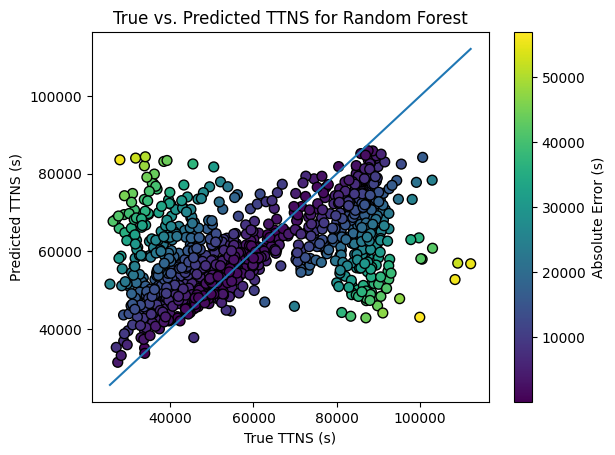

In [4]:
# Random Forest Analysis - values already unscaled from previous cell
y_test_secs = y_test_original
RF_pred_secs = random_forest_prediction

absolute_error_secs_RF = np.abs(RF_pred_secs - y_test_secs)

#Calculating true value, predicted, and average error in terms of seconds for each event
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, RF_pred_secs, absolute_error_secs_RF)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, RF_pred_secs, c=absolute_error_secs_RF, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Random Forest")
plt.show()